# Formaldehyde Monitoring in Anatomic Pathology Laboratory
### Data Institute | Data Science and AI Mini Project 1 | Anastasia Raspopina

## Introduction

Formaldehyde is a widely used chemical in pathology labs, primarily for tissue preservation. However, it is a **known carcinogen and respiratory irritant**, making environmental monitoring essential.

This project analyses data collected from **portable PPM HTV-M formaldehyde meters** to:

- Understand the **variability of exposure levels**
- Identify key **environmental factors** affecting concentration
- Evaluate **device reliability**
- Provide **safety recommendations** for workplace improsurments. The measurements have been taken in a real working environment in an Anatomic Pathology lab. It is known that tis prone totimes gets inaccurate measurementd also has cross-setoivity with some substances other than formaldehyde which appears as abnormaly high formaldehyde levels. It is also know that the temperature in the building never goes below 15 degrees. 

>  **Health & Safety Note**
>
> This analysis addresses real-world occupational safety issues. According to WorkSafe NZ:
> - The **legal ceiling** for formaldehyde exposure is **0.3 ppm**
> - The **recommended safe level** is **0.1 ppm**
>
> These thresholds apply to environments **without respiratory protection**. Keeping staff safe requires close monitoring and system reliability.


## Data Import and Cleaning

In [23]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from datetime import datetime
from sklearn.linear_model import LinearRegression

In [24]:
# Create an empty DataFrame 
formalin = pd.DataFrame()

In [25]:
# Add csv files to the DataFrame
directory = r"C:\Users\anast\OneDrive\Desktop\Meters_data\Meters" 
for filename in os.listdir(directory):
    if filename.endswith(".csv"):  
        file_path = os.path.join(directory, filename)  
        new_data = pd.read_csv(file_path, sep=';',encoding='utf-8')  
        formalin = pd.concat([formalin, new_data], ignore_index=True) 
formalin

,Date & Time,Reading/ppm,Temperature/oC,Humidity/%rh,Reading/mg.m^-3,Notes
0,23-Jan-2023 07:19:59,,20.42,62.8,,No Reading:Scheduled:Low battery power:Not rea...
1,23-Jan-2023 07:20:01,000.354,20.44,63.2,000.441,Scheduled
2,23-Jan-2023 07:27:33,000.193,20.19,64.4,000.241,Scheduled
3,23-Jan-2023 07:32:09,000.212,20.09,64.6,000.264,Scheduled
4,23-Jan-2023 07:37:05,000.192,19.99,64.7,000.240,Scheduled
...,...,...,...,...,...,...
148275,30-Jun-2023 07:30:01,000.071,20.73,48.5,000.088,Scheduled
148276,30-Jun-2023 07:35:01,000.037,20.98,48.2,000.046,Scheduled
148277,30-Jun-2023 07:40:01,000.042,21.12,47.8,000.052,Scheduled
148278,30-Jun-2023 07:45:01,000.045,21.19,47.9,000.056,Scheduled


In [26]:
# Convert Date & Time into datetime format
formalin['Date & Time'] = pd.to_datetime(formalin['Date & Time'], format='%d-%b-%Y %H:%M:%S')
formalin.head()

,Date & Time,Reading/ppm,Temperature/oC,Humidity/%rh,Reading/mg.m^-3,Notes
0,2023-01-23 07:19:59,,20.42,62.8,,No Reading:Scheduled:Low battery power:Not rea...
1,2023-01-23 07:20:01,000.354,20.44,63.2,000.441,Scheduled
2,2023-01-23 07:27:33,000.193,20.19,64.4,000.241,Scheduled
3,2023-01-23 07:32:09,000.212,20.09,64.6,000.264,Scheduled
4,2023-01-23 07:37:05,000.192,19.99,64.7,000.240,Scheduled


In [27]:
# Drop excessive columns: Notes (records if the measurment was autimatic or manually initiated, all readings in the lab are automatic)
# Readings/mg.m^-3' - only ppm readings are used for monitoring, so this column can be dropped too
formalin_clean = formalin.drop(columns=['Notes' , 'Reading/mg.m^-3']) 
formalin_clean.head()

,Date & Time,Reading/ppm,Temperature/oC,Humidity/%rh
0,2023-01-23 07:19:59,,20.42,62.8
1,2023-01-23 07:20:01,000.354,20.44,63.2
2,2023-01-23 07:27:33,000.193,20.19,64.4
3,2023-01-23 07:32:09,000.212,20.09,64.6
4,2023-01-23 07:37:05,000.192,19.99,64.7


In [28]:
# Rename columns with / and % symbols to exclude confusion
formalin_clean.rename(columns={'Reading/ppm':'Formaldehyde_Levels'}, inplace=True)
formalin_clean.rename(columns={'Temperature/oC':'Temperature'}, inplace=True)
formalin_clean.rename(columns={'Humidity/%rh':'Humidity'}, inplace=True)
formalin_clean

,Date & Time,Formaldehyde_Levels,Temperature,Humidity
0,2023-01-23 07:19:59,,20.42,62.8
1,2023-01-23 07:20:01,000.354,20.44,63.2
2,2023-01-23 07:27:33,000.193,20.19,64.4
3,2023-01-23 07:32:09,000.212,20.09,64.6
4,2023-01-23 07:37:05,000.192,19.99,64.7
...,...,...,...,...
148275,2023-06-30 07:30:01,000.071,20.73,48.5
148276,2023-06-30 07:35:01,000.037,20.98,48.2
148277,2023-06-30 07:40:01,000.042,21.12,47.8
148278,2023-06-30 07:45:01,000.045,21.19,47.9


In [29]:
# Check variables types
formalin_clean.dtypes

Date & Time            datetime64[ns]
Formaldehyde_Levels            object
Temperature                   float64
Humidity                      float64
dtype: object

In [30]:
# Replace object values in Reading/ppm with floats for future analysis
formalin_clean['Formaldehyde_Levels'] = pd.to_numeric(formalin_clean['Formaldehyde_Levels'], errors='coerce')

In [31]:
# Check types again if all object types were converted
formalin_clean.dtypes

Date & Time            datetime64[ns]
Formaldehyde_Levels           float64
Temperature                   float64
Humidity                      float64
dtype: object

In [32]:
# Check for null values in the columns
print("Null values found:\n", formalin_clean.isnull().sum() )

Null values found:
 Date & Time              0
Formaldehyde_Levels    713
Temperature              0
Humidity                 0
dtype: int64


In [33]:
# Drop null values
formalin_clean = formalin_clean.dropna() 

In [34]:
# Get dataframe info
formalin_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147567 entries, 1 to 148279
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Date & Time          147567 non-null  datetime64[ns]
 1   Formaldehyde_Levels  147567 non-null  float64       
 2   Temperature          147567 non-null  float64       
 3   Humidity             147567 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 5.6 MB


Get basic statistics and check for odd measurments (high/low temperature, extremely high formaldehyde concentrations, extremely low humidity)

In [35]:
# Exclude Date & Time column
formalin_clean.loc[:, formalin_clean.columns!= 'Date & Time'].describe()

,Formaldehyde_Levels,Temperature,Humidity
count,147567.000000,147567.000000,147567.000000
mean,0.090486,20.377635,58.715181
std,0.057438,1.769035,8.867351
min,0.000000,-0.010000,0.000000
25%,0.057000,19.610000,53.900000
50%,0.079000,20.400000,60.000000
75%,0.111000,21.290000,64.700000
max,4.978000,24.040000,102.300000


In [36]:
# Drop readings above 0.5 ppm as not accurate or results of a cross-sensitivity with other reagents
formalin_clean = formalin_clean[formalin_clean['Formaldehyde_Levels'] < 0.5]

In [37]:
# Drop temperature below 15oC as not accurate
formalin_clean = formalin_clean[formalin_clean.Temperature > 15.0]

In [47]:
# Drop humidity below 30% as not accurate
formalin_clean = formalin_clean[formalin_clean.Humidity > 30.0]

In [48]:
# Get a new description
formalin_clean.loc[:, formalin_clean.columns!= 'Date & Time'].describe()

,Formaldehyde_Levels,Temperature,Humidity
count,145638.000000,145638.000000,145638.000000
mean,0.089704,20.461712,58.818909
std,0.047721,1.117660,7.728631
min,0.000000,15.080000,30.100000
25%,0.057000,19.620000,54.000000
50%,0.079000,20.400000,60.000000
75%,0.111000,21.290000,64.700000
max,0.499000,24.000000,77.900000


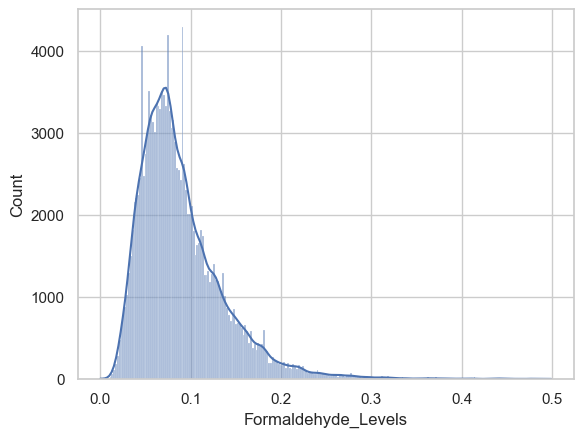

In [39]:
# Plot a histogram of formaldehyde levels to visualise the numeric distribution
sns.histplot(formalin_clean['Formaldehyde_Levels'], kde=True)
plt.show()

As the histogram is skewed left, median is more preferred for emissions analysis and further work planning

<Axes: >

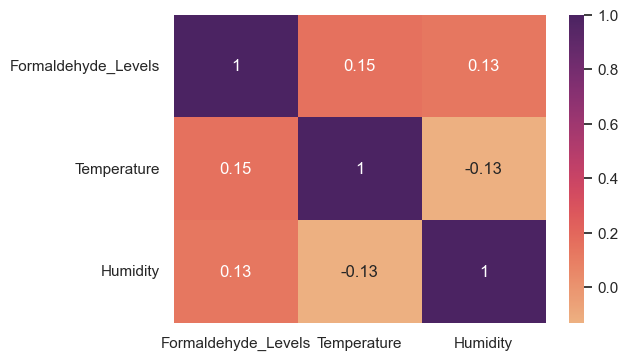

In [49]:
# Calculate and plot a correlation between the measurments
sns.set(rc={'figure.figsize':(6, 4)})
corr = formalin_clean.loc[:, formalin_clean.columns!= 'Date & Time'].corr()
sns.heatmap(corr, cmap = 'flare', annot= True) 

## Exploratory Data Analysis

We explored how formaldehyde levels vary with:
- **Time of day**
- **Temperature**
- **Humidity**
- **Shifts**


### Formaldehyde Levels by Hour of Day


In [41]:
# Ensure the datetime is correct
formalin_clean['Date & Time'] = pd.to_datetime(formalin_clean['Date & Time'])
formalin_clean['Formaldehyde_Levels'] = pd.to_numeric(formalin_clean['Formaldehyde_Levels'], errors='coerce')
formalin_clean = formalin_clean.dropna(subset=['Formaldehyde_Levels'])

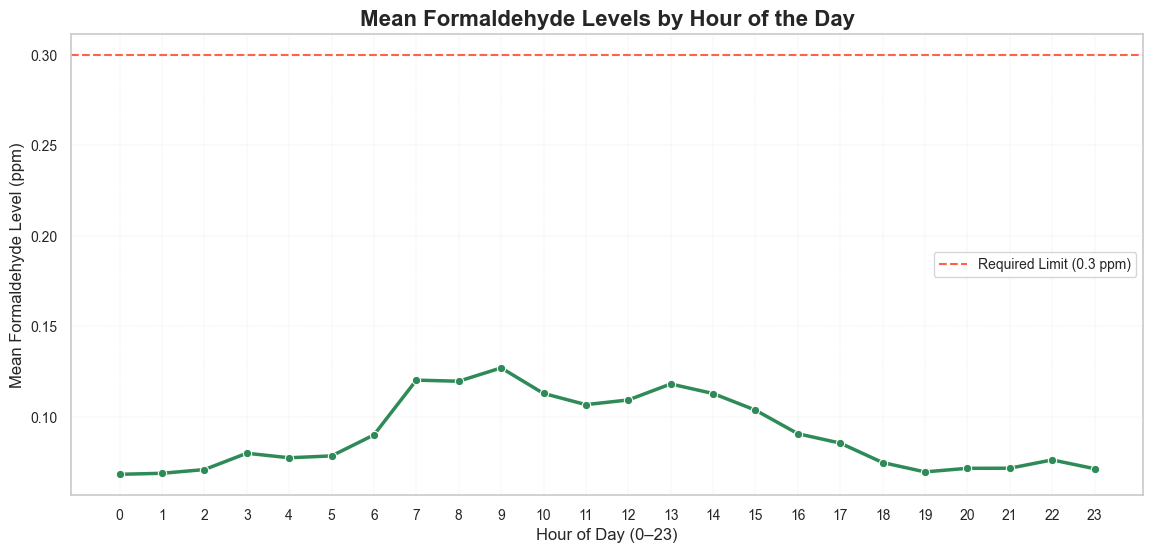

In [44]:
# Create the plot
plt.figure(figsize=(12, 6))
palette = sns.color_palette("crest", as_cmap=True)

# Plot with markers and line
sns.lineplot(x=hourly_means.index,
             y=hourly_means.values,
             marker='o',
             linewidth=2.5,
             color='seagreen')

# Define a horizontal guideline for safe exposure level
safe_limit = 0.3
plt.axhline(safe_limit, color='tomato', linestyle='--', linewidth=1.5, label='Required Limit (0.3 ppm)')

# Labels and title
plt.title('Mean Formaldehyde Levels by Hour of the Day', fontsize=16, weight='bold')
plt.xlabel('Hour of Day (0–23)', fontsize=12)
plt.ylabel('Mean Formaldehyde Level (ppm)', fontsize=12)

# Ticks and grid
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', linewidth=0.3)

# Legend and layout
plt.legend(fontsize=10)
plt.tight_layout(pad=2)

# Show the plot
plt.show()

# Temperature and humidity fluctuations effects

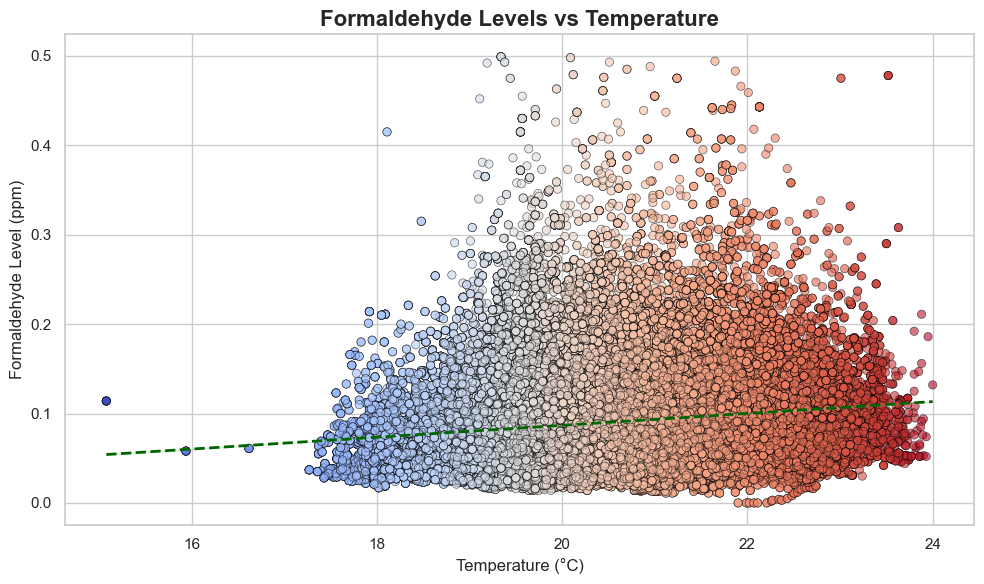

In [43]:
# Plot formaldehyde levels vs temperature

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.scatterplot(
    data=formalin_clean,
    x='Temperature',
    y='Formaldehyde_Levels',
    hue='Temperature',
    palette='coolwarm',
    edgecolor='black',
    alpha=0.6
)

# Add regression line 
sns.regplot(
    data=formalin_clean,
    x='Temperature',
    y='Formaldehyde_Levels',
    scatter=False,
    color='darkgreen',
    line_kws={"linewidth": 2, "linestyle": '--'}
)

# Title and labels
plt.title('Formaldehyde Levels vs Temperature', fontsize=16, weight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Formaldehyde Level (ppm)', fontsize=12)
plt.legend([],[], frameon=False)  # Hides legend if not needed

plt.tight_layout()
plt.show()

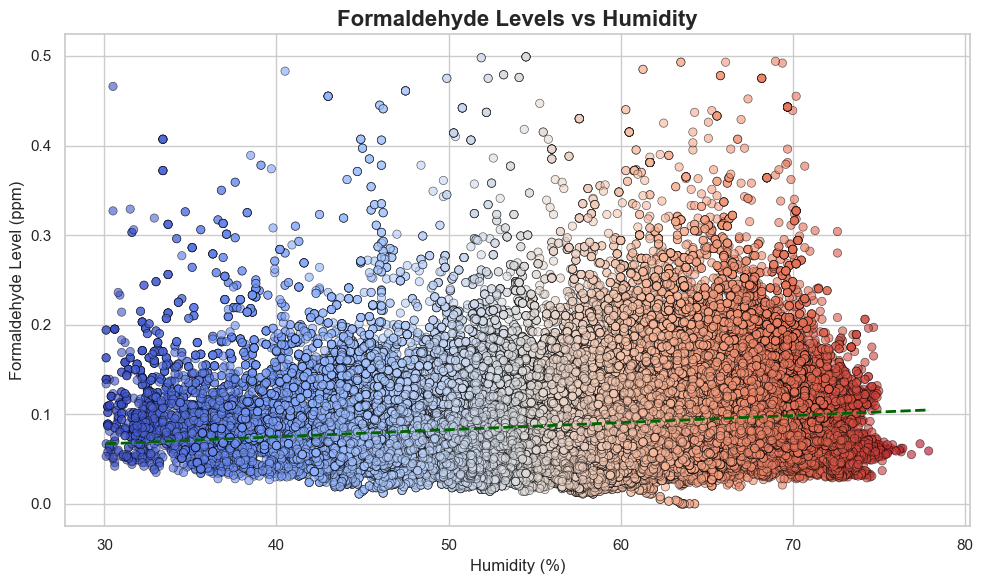

In [54]:
# Plot formaldehyde levels vs humidity

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.scatterplot(
    data=formalin_clean,
    x='Humidity',
    y='Formaldehyde_Levels',
    hue='Humidity',
    palette='coolwarm',
    edgecolor='black',
    alpha=0.6
)

# Add regression line 
sns.regplot(
    data=formalin_clean,
    x='Humidity',
    y='Formaldehyde_Levels',
    scatter=False,
    color='darkgreen',
    line_kws={"linewidth": 2, "linestyle": '--'}
)

# Title and labels
plt.title('Formaldehyde Levels vs Humidity', fontsize=16, weight='bold')
plt.xlabel('Humidity (%)', fontsize=12)
plt.ylabel('Formaldehyde Level (ppm)', fontsize=12)
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

As it is known that during the day shift there are always 5 people working at the same time, while during the night shift there are only 2 people working, it's possible to calculate the formaldehyde levels difference between shifts.
To do that we need to define the time ranges for both shifts and then group meter readings by these time ranges

In [55]:
# Define the time ranges for day shift and night shift
dayshift_start = pd.to_datetime('05:00:00').time()
dayshift_end = pd.to_datetime('17:00:00').time()
nightshift_start = pd.to_datetime('17:00:01').time()
nightshift_end = pd.to_datetime('23:59:59').time()
nightshift_start_2 = pd.to_datetime('00:00:00').time()
nightshift_end_2 = pd.to_datetime('04:59:59').time()

In [56]:
# Distribute working hours between the shifts
formalin_clean['Working_Time'] = formalin_clean['Date & Time'].apply(lambda x: 'Day Shift' 
        if dayshift_start <= x.time() <= dayshift_end 
        else 'Night Shift' if (nightshift_start <= x.time() <= nightshift_end) 
        or (nightshift_start_2 <= x.time() <= nightshift_end_2) 
        else 'Other')

In [57]:
# Group data by time period
grouped_data = formalin_clean.groupby('Working_Time')

In [58]:
# Calculate median for each shift
median_per_group = grouped_data['Formaldehyde_Levels'].median()
median_per_group

Working_Time
Day Shift      0.097
Night Shift    0.069
Name: Formaldehyde_Levels, dtype: float64

# Plot medians
median_per_group.plot(kind="bar")

# Labels and title
plt.xlabel('Time')
plt.ylabel('Median Concentration')
plt.suptitle('Shifts Median')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

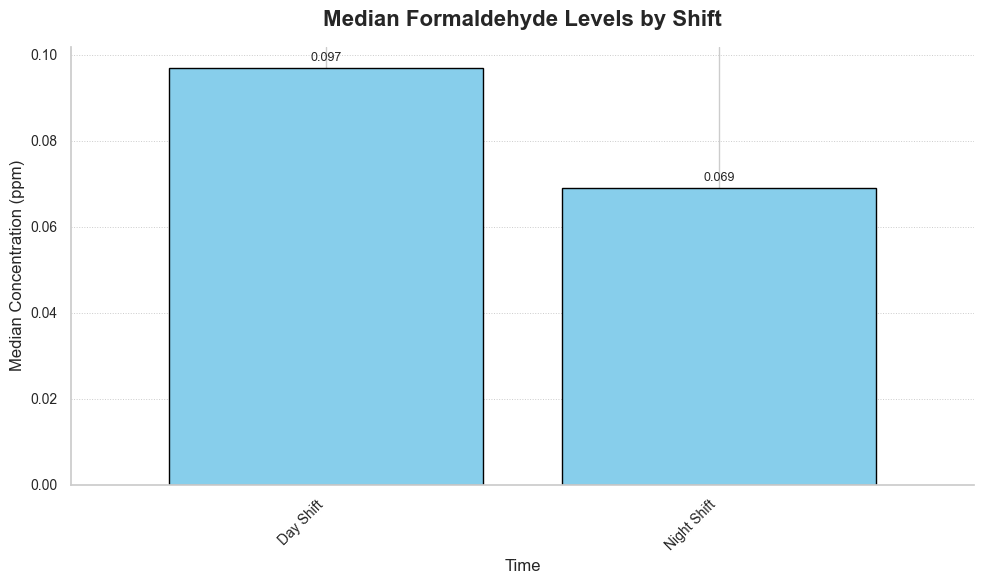

In [62]:
# Use seaborn styling
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))
ax = median_per_group.plot(kind="bar", color='skyblue', edgecolor='black', width=0.8)

# Customize title and labels
ax.set_title('Median Formaldehyde Levels by Shift', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Median Concentration (ppm)', fontsize=12)

# Customize tick labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Add gridlines
ax.grid(True, which='major', axis='y', linestyle=':', linewidth=0.7)

# Remove top and right spines for cleaner look
sns.despine()

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

## Summary of Findings

1. **Occupancy** strongly affects formaldehyde levels — peak concentrations align with shift overlaps.
2. **Temperature control** helps but need not be uncomfortable for staff.
3. More stations may occurevent p, although the **WorkSafe limit of 5 people is justified**.
4. The current meter model is **outdated**, prone to errors, and needs replacement.



## Recommendations

- Upgrade to **modern formaldehyde meters** with wireless logging
- Limit the Grossing Area to **5 personnel max**
- Monitor and maintain **ventilation performance**
